In [2]:
import os

from physics.hstar import c6
from physics.hzz import zz4l, zpair
from physics.simulation import mcfm, msq

import numpy as np
import matplotlib.pyplot as plt

import hist

In [39]:
SAMPLE_DIR = '../../data'
SAMPLE_SIZE = 4000000
COMPONENT = msq.Component.SBI

luminosity = 3000

In [40]:
filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

In [41]:
filename_qqZZ = 'qqZZ2e2m.csv'
xs_qqZZ = 14.482054

In [47]:
events_ggZZ = mcfm.from_csv(cross_section=xs[COMPONENT], file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT]), n_rows=int(1.2*SAMPLE_SIZE))
events_qqZZ = mcfm.from_csv(cross_section=xs_qqZZ, file_path=os.path.join(SAMPLE_DIR, filename_qqZZ), n_rows=int(1.2*SAMPLE_SIZE))

bkg_null_filter = msq.MSQFilter('msq_bkg_sm', value=0.0)

z_candidate = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZPairMassWindow(z1 = (70,115), z2 = (70,115))

angles = zz4l.AngularVariables()
four_lepton = zz4l.FourLeptonSystem()
lepton_momenta = zz4l.LeptonMomenta()

events_ggZZ_processed = events_ggZZ.filter(bkg_null_filter).calculate(z_candidate).filter(z_masses).calculate(angles).calculate(four_lepton).calculate(lepton_momenta)[:SAMPLE_SIZE]
events_qqZZ_processed = events_qqZZ.calculate(z_candidate).filter(z_masses).calculate(angles).calculate(four_lepton).calculate(lepton_momenta)[:SAMPLE_SIZE]

15.573816383864997
144.82364822627704


In [48]:
features = ['4l_mass']#['l1_pt', 'l2_pt', 'l3_pt', 'l4_pt', 'l1_eta', 'l2_eta', 'l3_eta', 'l4_eta', 'l1_phi', 'l2_phi', 'l3_phi', 'l4_phi']
# Get only required features
kinematics_ggZZ = events_ggZZ_processed.kinematics[features].to_numpy()
kinematics_qqZZ = events_qqZZ_processed.kinematics[features].to_numpy()

In [49]:
print(f'# of ggZZ: {kinematics_ggZZ.shape[0]}, # of qqZZ: {kinematics_qqZZ.shape[0]}')

# of ggZZ: 2856608, # of qqZZ: 2629072


In [50]:
mod_c6 = c6.Modifier(baseline = COMPONENT, events=events_ggZZ_processed, c6_values = [-5,-1,0,1,5])
weights_c6, prob_c6 = mod_c6.modify(c6=[-10,0,10])

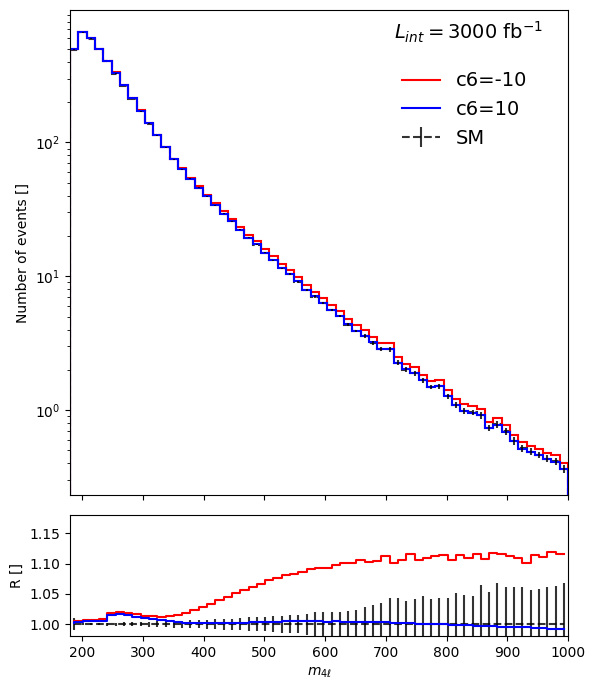

In [ ]:
index = 0

kin_var = kinematics_ggZZ[:,index]
'''label = ['$\mathrm{cos}(\\theta^*)$ []',
         '$\mathrm{cos}(\\theta_1)$ []',
         '$\mathrm{cos}(\\theta_2)$ []',
         '$\phi$ []',
         '$\phi_1$ []',
         '$m_{Z1}$ [GeV]',
         '$m_{Z2}$ [GeV]',
         '$m_{4\ell}$ [GeV]',
         '$y_{4\ell}$ []'][index]
bounds = [[-1,1],
          [-1,1],
          [-1,1],
          [-np.pi,np.pi],
          [-np.pi,np.pi],
          [70,115],
          [70,115],
          [160,1000],
          [-2.4,2.4]][index]'''


label = ['$m_{4\ell}$'][index]
bounds = [[180,1000]][index]


BINS=60

hist_sm = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_sm.fill(kin_var, weight=weights_c6.T[1]*luminosity)

hist_c6_1 = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_c6_1.fill(kin_var, weight=weights_c6.T[0]*luminosity)

hist_c6_2 = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_c6_2.fill(kin_var, weight=weights_c6.T[2]*luminosity)

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

hist_sm.plot(ax=ax1, color='k', linestyle='--', label=f'SM', alpha=0.8, yerr=np.sqrt(hist_sm.variances()))
hist_c6_1.plot(ax=ax1, color='r', label=f'c6=-10', yerr=False)
hist_c6_2.plot(ax=ax1, color='b', label=f'c6=10', yerr=False)

ax1.text(0.65, 0.98, f'$L_{{int}} = {luminosity}$ fb$^{{-1}}$', transform=ax1.transAxes, fontsize=14, verticalalignment='top')

ax1.set_ylabel('Number of events []')
ax1.set_yscale('log')
ax1.set_xlim(*bounds)
ax1.set_xlabel('')

ax1.legend(frameon=False, fontsize=14, loc=[0.65,0.7])

#hist_sm.plot_ratio(hist_sm)
#hist_c6_1.plot_ratio(hist_sm)
#hist_c6_2.plot_ratio(hist_sm)

ax2.errorbar(hist_sm.axes[0].centers, hist_sm.values()/hist_sm.values(), yerr=np.sqrt(hist_sm.variances())/hist_sm.values(), color='black', linestyle='--', drawstyle='steps-pre', alpha=0.8)
ax2.errorbar(hist_sm.axes[0].centers, hist_c6_1.values()/hist_sm.values(), color='r', drawstyle='steps-pre')
ax2.errorbar(hist_sm.axes[0].centers, hist_c6_2.values()/hist_sm.values(), color='b', drawstyle='steps-pre')
         
ax2.set_xlabel(label)
ax2.set_ylabel('R []')
#ax2.set_yscale('log')
ax2.set_ybound(0.98,1.18)
ax2.set_xlim(*bounds)
fig.tight_layout()

plt.show()

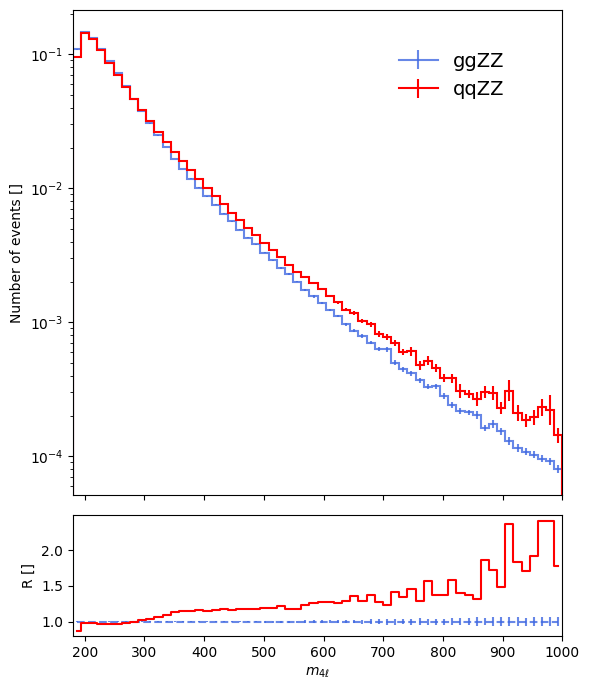

In [ ]:
index = 0

kin_var_ggZZ = kinematics_ggZZ[:,index]
kin_var_qqZZ = kinematics_qqZZ[:,index]

label = ['$m_{4\ell}$'][index]
bounds = [[180,1000]][index]


BINS=60

hist_ggZZ = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_ggZZ.fill(kin_var_ggZZ, weight=events_ggZZ_processed.probabilities)

hist_qqZZ = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_qqZZ.fill(kin_var_qqZZ, weight=events_qqZZ_processed.probabilities)

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

hist_ggZZ.plot(ax=ax1, color='royalblue', label=f'ggZZ', alpha=0.8)
hist_qqZZ.plot(ax=ax1, color='red', label=f'qqZZ')

#ax1.text(0.65, 0.98, f'$L_{{int}} = {luminosity}$ fb$^{{-1}}$', transform=ax1.transAxes, fontsize=14, verticalalignment='top')

ax1.set_ylabel('Probability []')
ax1.set_yscale('log')
ax1.set_xlim(*bounds)
ax1.set_xlabel('')

ax1.legend(frameon=False, fontsize=14, loc=[0.65,0.80])

#hist_sm.plot_ratio(hist_sm)
#hist_c6_1.plot_ratio(hist_sm)
#hist_c6_2.plot_ratio(hist_sm)

ax2.errorbar(hist_ggZZ.axes[0].centers, hist_ggZZ.values()/hist_ggZZ.values(), yerr=np.sqrt(hist_ggZZ.variances())/hist_ggZZ.values(), color='royalblue', linestyle='--', drawstyle='steps-mid', alpha=0.8)
ax2.errorbar(hist_qqZZ.axes[0].centers, hist_qqZZ.values()/hist_ggZZ.values(), color='red', drawstyle='steps-mid')
         
ax2.set_xlabel(label)
ax2.set_ylabel('R []')
#ax2.set_yscale('log')
#ax2.set_ybound(0.98,1.18)
ax2.set_xlim(*bounds)
fig.tight_layout()

plt.show()

In [36]:
index = 3

kin_var = kinematics[:,index]
'''label = ['$\mathrm{cos}(\\theta^*)$ []',
         '$\mathrm{cos}(\\theta_1)$ []',
         '$\mathrm{cos}(\\theta_2)$ []',
         '$\phi$ []',
         '$\phi_1$ []',
         '$m_{Z1}$ [GeV]',
         '$m_{Z2}$ [GeV]',
         '$m_{4\ell}$ [GeV]',
         '$y_{4\ell}$ []'][index]
bounds = [[-1,1],
          [-1,1],
          [-1,1],
          [-np.pi,np.pi],
          [-np.pi,np.pi],
          [70,115],
          [70,115],
          [160,1000],
          [-2.4,2.4]][index]'''


label = ['$\ell_1 p_T$ [GeV]',
         '$\ell_2 p_T$ [GeV]',
         '$\ell_3 p_T$ [GeV]',
         '$\ell_4 p_T$ [GeV]',
         '$\ell_1 \eta$ []',
         '$\ell_2 \eta$ []',
         '$\ell_3 \eta$ []',
         '$\ell_4 \eta$ []',
         '$\ell_1 \phi$ []',
         '$\ell_2 \phi$ []',
         '$\ell_3 \phi$ []',
         '$\ell_4 \phi$ []'][index]
bounds = [[10,450],
          [0,400],
          [0,240],
          [0,170],
          [-2.9,2.9],
          [-2.9,2.9],
          [-2.9,2.9],
          [-2.9,2.9],
          [-np.pi,np.pi],
          [-np.pi,np.pi],
          [-np.pi,np.pi],
          [-np.pi,np.pi]][index]

BINS=50


sbi_weights = events_processed.reweight(COMPONENT, msq.Component.SBI).weights
sbi_weights *= xs[msq.Component.SBI]/sbi_weights.sum()
bkg_weights = events_processed.reweight(COMPONENT, msq.Component.BKG).weights
bkg_weights *= xs[msq.Component.BKG]/bkg_weights.sum()
sig_weights = events_processed.reweight(COMPONENT, msq.Component.SIG).weights
sig_weights *= xs[msq.Component.SIG]/sig_weights.sum()
int_weights = events_processed.reweight(COMPONENT, msq.Component.INT).weights
int_weights *= xs[msq.Component.INT]/int_weights.sum()

hist_sbi = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_sbi.fill(kin_var, weight=sbi_weights)

hist_bkg = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_bkg.fill(kin_var, weight=bkg_weights)

hist_sig = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_sig.fill(kin_var, weight=sig_weights)

hist_int = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_int.fill(kin_var, weight=int_weights)

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

hist_sbi.plot(ax=ax1, color='k', linestyle='--', label=f'SBI', alpha=0.8, yerr=np.sqrt(hist_sbi.variances()))
hist_bkg.plot(ax=ax1, color='r', label=f'BKG', yerr=False)
hist_sig.plot(ax=ax1, color='b', label=f'SIG', yerr=False)
hist_int.plot(ax=ax1, color='g', label=f'INT', yerr=False)

ax1.set_ylabel('Number of events []')
#ax1.set_yscale('log')
ax1.set_xlim(*bounds)
ax1.set_xlabel('')

ax1.legend()

#hist_sm.plot_ratio(hist_sm)
#hist_c6_1.plot_ratio(hist_sm)
#hist_c6_2.plot_ratio(hist_sm)

ax2.errorbar(hist_sbi.axes[0].edges[:-1], hist_sbi.values()/hist_sbi.values(), yerr=np.sqrt(hist_sbi.variances())/hist_sbi.values(), color='black', linestyle='--', drawstyle='steps-mid', alpha=0.8)
ax2.errorbar(hist_bkg.axes[0].edges[:-1], hist_bkg.values()/hist_sbi.values(), color='r', drawstyle='steps-mid')
ax2.errorbar(hist_sig.axes[0].edges[:-1], hist_sig.values()/hist_sbi.values(), color='b', drawstyle='steps-mid')
ax2.errorbar(hist_int.axes[0].edges[:-1], hist_int.values()/hist_sbi.values(), color='b', drawstyle='steps-mid')

ax2.set_xlabel(label)
ax2.set_ylabel('R []')
#ax2.set_yscale('log')
ax2.set_ybound(0,2)
ax2.set_xlim(*bounds)
fig.tight_layout()

plt.show()

IndexError: index 3 is out of bounds for axis 1 with size 1